# Train new Anisotropy model with RFR + bagging

Requires environment defined in /environment-jpnb.yml

## Settings

In [14]:
# using IPython to autoreload modules when they are edited
%load_ext autoreload
%autoreload 2

BASE_PATH: /home/wager/projects/PUBLICATION/magnetic-uncertainty
DATA_PATH: /home/wager/projects/PUBLICATION/magnetic-uncertainty/data
MODEL_PATH: /home/wager/projects/PUBLICATION/magnetic-uncertainty/models
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import random
import joblib
from sklearn.model_selection import KFold
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from evaluation.residual import plot_cv_predictions_color_std
from evaluation.confidence import plot_confidence
from util import load_experimental, get_timestamp_as_string, DATA_PATH, MODEL_PATH
print('Imports OK')

Imports OK


In [16]:
TS = get_timestamp_as_string()
print(f"Timestamp: {TS}")
symbol = r"$\mu_0H_\mathrm{a}$"
MODEL_SAVE_PATH = MODEL_PATH / "Ha_rfr_bagging" / TS
MODEL_SAVE_PATH.mkdir(parents=True, exist_ok=True)
SEED = 123
np.random.seed(SEED)
random.seed(SEED)

Timestamp: 2026-01-19__20-00-51


# Train new model 

## Get data

In [17]:
# Load experimental data
df = load_experimental(file_name="2025-06-05_physical_properties.csv", dir_name=DATA_PATH)
print(f"loaded initial data with shape: {df.shape}")

Load data from '2025-06-05_physical_properties.csv'
No features provided for duplicate removal. Using default features: ['Nd', 'Ce', 'La', 'Pr', 'Y', 'Tb', 'Dy', 'Fe', 'Co', 'Ni', 'B', 'C', 'temp']
Dropped 40 duplicates.
Applied sphere transform to elemental features.
Scaled 'temp' feature to 'temp_s' by dividing by max temp.
loaded initial data with shape: (1479, 39)


In [18]:
# Select scaled data
features_physics = ['Nd_s', 'Ce_s', 'La_s', 'Pr_s', 'Y_s', 'Tb_s', 'Dy_s', 'Fe_s', 'Co_s', 'Ni_s', 'B_s', 'C_s', "temp_s"]
df = df[features_physics + ["Ha"]].copy()

# Split data into features and target
X = df.drop("Ha", axis=1)
y = df["Ha"]

## Create model

### Define Custom Wrapper Class

In [19]:
class UncertaintyBaggingRegressor(BaseEstimator, RegressorMixin):
    """
    Wrapper around BaggingRegressor (or any ensemble) to provide predictive uncertainty
    via the standard deviation of predictions across estimators.
    """

    def __init__(self, base_estimator, n_estimators, random_state=None):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.model = None

    def fit(self, X, y):
        from sklearn.ensemble import BaggingRegressor
        self.model = BaggingRegressor(
            estimator=self.base_estimator,
            n_estimators=self.n_estimators,
            random_state=self.random_state
        )
        self.model.fit(X, y)
        return self

    def predict(self, X, return_std=True, ci=1.96):
        """
        Predict target values. If return_std=True, also return predictive uncertainty (CI).
        :param X: Input features.
        :param return_std: Whether to return the standard deviation of predictions.
        :param ci: Confidence interval multiplier (default is 1.96 for 95% CI).
        """
        y_pred = self.model.predict(X)

        if return_std:
            # Collect predictions from each estimator in the ensemble
            all_preds = np.array([est.predict(X) for est in self.model.estimators_])
            std = ci * np.std(all_preds, axis=0)
            return y_pred, std
        return y_pred

    def get_estimators(self):
        return self.model.estimators_

### Fit model

In [20]:
# Create custom model
n_trees = 50  # was 100
n_estimators = 100  # was 200

regressor = UncertaintyBaggingRegressor(
    base_estimator=RandomForestRegressor(
        n_estimators=n_trees,
        random_state=SEED, 
    ),
    n_estimators=n_estimators,
    random_state=SEED
)

In [21]:
# Fit the model
print("fitting regressor for prediction ...")
regressor.fit(X, y.values)

fitting regressor for prediction ...


UncertaintyBaggingRegressor(base_estimator=RandomForestRegressor(n_estimators=50,
                                                                 random_state=123),
                            n_estimators=100, random_state=123)

### Write model architecture to file and output 

In [22]:
# Write model summary to file for RandomForestRegressor
model_summary_path = MODEL_SAVE_PATH / "ha_model_summary.txt"

summary_lines = [
    "RandomForestRegressor (Bagging) Summary",
    "*" * 80,
    f"Number of Trees in Base RandomForest: {n_trees}",
    f"Number of Bagging Estimators: {regressor.n_estimators}",
    f"Random State: {regressor.random_state}",
]

# Include base estimator details
if hasattr(regressor, "base_estimator_") or hasattr(regressor, "base_estimator"):
    base_est = getattr(regressor, "base_estimator_", regressor.base_estimator)
    if hasattr(base_est, "n_estimators"):
        summary_lines.append(f"Base Estimator (RandomForest) - n_estimators: {base_est.n_estimators}")
    if hasattr(base_est, "max_depth"):
        summary_lines.append(f"Base Estimator (RandomForest) - max_depth: {base_est.max_depth}")
    if hasattr(base_est, "random_state"):
        summary_lines.append(f"Base Estimator (RandomForest) - random_state: {base_est.random_state}")

# Training data info
if hasattr(regressor, "estimators_") and len(regressor.estimators_) > 0:
    try:
        n_samples, n_features = regressor.estimators_[0].n_features_in_, len(regressor.estimators_[0].feature_importances_)
        summary_lines.append(f"Training samples: {n_samples}")
        summary_lines.append(f"Number of features: {n_features}")
    except AttributeError:
        pass

# Feature importances (mean over all base estimators)
if hasattr(regressor, "estimators_") and len(regressor.estimators_) > 0:
    importances = np.mean([est.feature_importances_ for est in regressor.estimators_], axis=0)
    summary_lines.append(f"Feature importances (mean over estimators): {importances}")

summary = "\n".join(summary_lines)

# Print and save to file
print(summary)
with open(model_summary_path, "w") as f:
    f.write(summary)


RandomForestRegressor (Bagging) Summary
********************************************************************************
Number of Trees in Base RandomForest: 50
Number of Bagging Estimators: 100
Random State: 123
Base Estimator (RandomForest) - n_estimators: 50
Base Estimator (RandomForest) - max_depth: None
Base Estimator (RandomForest) - random_state: 123


### Save model to disk

In [23]:
# Define save path
model_path = MODEL_SAVE_PATH / "ha_model.pkl"
# Save the trained regressor
joblib.dump(regressor, model_path)
print(f"Model saved to {model_path}")

Model saved to /home/wager/projects/PUBLICATION/magnetic-uncertainty/models/Ha_rfr_bagging/2026-01-19__20-00-51/ha_model.pkl


# Evaluation

## Prediction accuracy

### Perform 5-fold cross validation

In [27]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

model_name = "Ha_rfr_bagging"
y_pred_cv_all = np.zeros_like(y, dtype=float)
y_std_cv_all = np.zeros_like(y, dtype=float)

mae_scores = []
mse_scores = []
r2_scores = []

for i, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\nFitting for cross-validation split {i+1}/{n_splits} ...\n")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Clone regressor for each fold
    model = clone(regressor)

    model.fit(X_train.values, y_train)
    y_pred_fold, y_std_fold = model.predict(X_val.values, return_std=True)

    y_pred_cv_all[val_idx] = y_pred_fold
    y_std_cv_all[val_idx] = y_std_fold

    # Compute metrics for this fold
    mae_scores.append(mean_absolute_error(y_val, y_pred_fold))
    mse_scores.append(mean_squared_error(y_val, y_pred_fold))
    r2_scores.append(r2_score(y_val, y_pred_fold))

# Compute averages
mae_cv_avg = np.mean(mae_scores)
mse_cv_avg = np.mean(mse_scores)
r2_cv_avg = np.mean(r2_scores)

print(f"{model_name} - MAE: {mae_cv_avg:.4f}, MSE: {mse_cv_avg:.4f}, R2: {r2_cv_avg:.4f}")
print(f"{model_name} - mean predictive std: {y_std_cv_all.mean():.4f}")


Fitting for cross-validation split 1/5 ...


Fitting for cross-validation split 2/5 ...


Fitting for cross-validation split 3/5 ...


Fitting for cross-validation split 4/5 ...


Fitting for cross-validation split 5/5 ...

Ha_rfr_bagging - MAE: 0.3477, MSE: 0.3598, R2: 0.9397
Ha_rfr_bagging - mean predictive std: 0.4005


### Plot predictive performance

#### Upper plot with std color

/home/wager/projects/PUBLICATION/magnetic-uncertainty/source/evaluation/src/residual.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,       # left


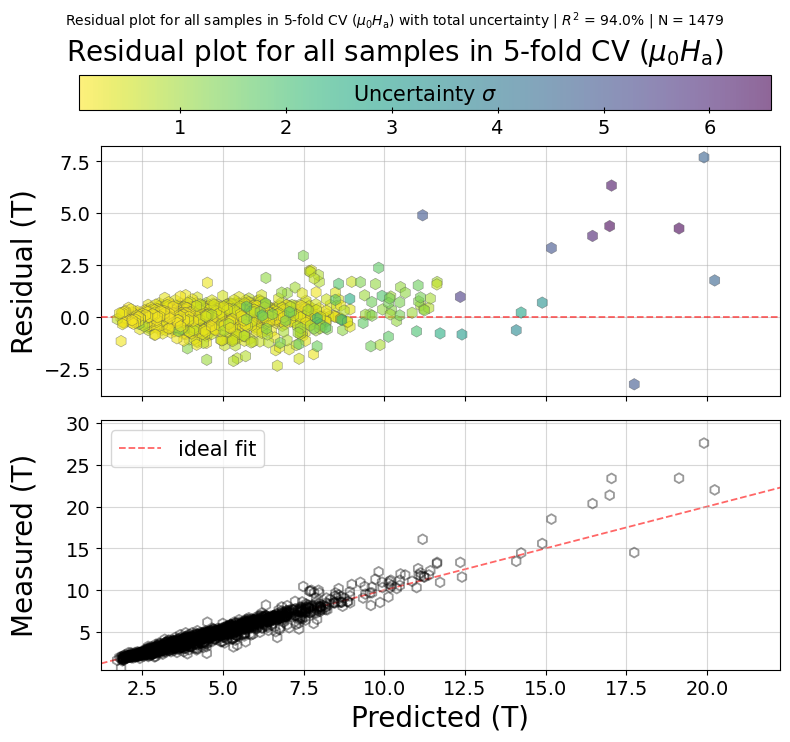

Saved to dir /home/wager/projects/PUBLICATION/magnetic-uncertainty/models/Ha_rfr_bagging/2026-01-19__20-00-51


In [25]:
title = f"Residual plot for all samples in 5-fold CV ({symbol})"
plot_cv_predictions_color_std(y_pred_cv_all, y, y_std_cv_all, 
                              title=title, 
                              details=title+' with total uncertainty',     
                              filename='Ha_all_samples_total_unc', 
                              dirname=MODEL_SAVE_PATH)

## The Confidence Curve

### Randomly seeded confidence curve

Fixed random seed: 123
Trial 1/10: fitting ...


/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/skle

Fixed random seed: 124
Trial 2/10: fitting ...


/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/skle

Fixed random seed: 125
Trial 3/10: fitting ...


...

/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/skle

Fixed random seed: 131
Trial 9/10: fitting ...


/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/skle

Fixed random seed: 132
Trial 10/10: fitting ...


/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wager/micromamba/envs/paper-magnetic-uncertainty/lib/python3.10/site-packages/skle

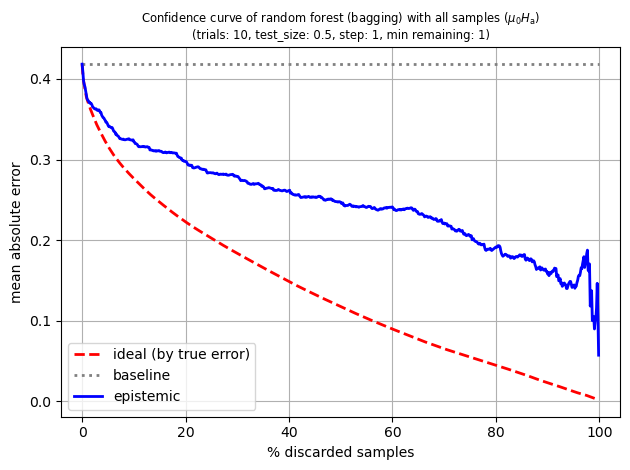

Saved to file: /home/wager/projects/PUBLICATION/magnetic-uncertainty/models/Ha_rfr_bagging/2026-01-19__20-00-51/confidence_curve_Ha_all_samples.png


In [26]:
plot_confidence(
    regressor=regressor,
    df=df,
    features=features_physics,
    label="Ha",
    output_dir=MODEL_SAVE_PATH,
    plot_name=f"confidence_curve_Ha_all_samples",
    title=f"Confidence curve of random forest (bagging) with all samples ({symbol})",
    seed=SEED,
    metric="mae",
    n_trials=10,
    test_size=0.5,
    plot_std_total_only=True,
    min_remaining=1,
    step=1
)